In [1]:
import pandas as pd

#Load datasets
customers = pd.read_csv('python_project_aiml_logicmojo_dataset/customers.csv')
category_translation = pd.read_csv('python_project_aiml_logicmojo_dataset/category_translation.csv')
location = pd.read_csv('python_project_aiml_logicmojo_dataset/location.csv')
order_item = pd.read_csv('python_project_aiml_logicmojo_dataset/order_item.csv')
orders = pd.read_csv('python_project_aiml_logicmojo_dataset/orders.csv')
payments = pd.read_csv('python_project_aiml_logicmojo_dataset/payments.csv')
products = pd.read_csv('python_project_aiml_logicmojo_dataset/products.csv')
reviews = pd.read_csv('python_project_aiml_logicmojo_dataset/reviews.csv')
sellers = pd.read_csv('python_project_aiml_logicmojo_dataset/sellers.csv')

#Use Head
print(customers.head())
print(category_translation.head())
print(location.head())
print(order_item.head())
print(orders.head())
print(payments.head())
print(products.head())
print(reviews.head())
print(sellers.head())



                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         compute

In [2]:
#See null features
orders.isna().sum()
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
#Convert to datetime format
orders[date_cols] = orders[date_cols].apply(pd.to_datetime)
#Fill empty values
#Approved on the date of purchase
orders['order_approved_at'] = orders['order_approved_at'].fillna(orders['order_purchase_timestamp'])
#Forward fill
orders['order_delivered_carrier_date'] = orders['order_delivered_carrier_date'].ffill()
#Drop if not delivered
orders = orders.dropna(subset=['order_delivered_customer_date'])

In [3]:
orders.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [4]:
payments.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [5]:
products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [6]:
products['product_category_name']= products['product_category_name'].fillna(products['product_category_name'].mode()[0])
products['product_name_lenght']= products['product_name_lenght'].fillna(products['product_name_lenght'].mode()[0])
products['product_photos_qty']= products['product_photos_qty'].fillna(products['product_photos_qty'].mode()[0])
products['product_description_lenght']= products['product_description_lenght'].fillna(products['product_description_lenght'].mode()[0])
products.isna().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              2
product_length_cm             2
product_height_cm             2
product_width_cm              2
dtype: int64

In [7]:
customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [8]:
category_translation.isna().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [9]:
location.isna().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [10]:
order_item.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [11]:
#Remove columns with a lot of null values
reviews = reviews.drop(columns=['review_comment_title'])
reviews = reviews.drop('review_comment_message', axis='columns')
reviews.isna().sum()

review_id                  0
order_id                   0
review_score               0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [12]:
sellers.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [13]:
#Duplicate remove
sellers.duplicated().sum()
reviews.duplicated().sum()
order_item.duplicated().sum()

location.duplicated(subset='geolocation_zip_code_prefix').sum()
location.drop_duplicates(subset=['geolocation_zip_code_prefix'], inplace=True)
location.duplicated(subset='geolocation_zip_code_prefix').sum()

category_translation.duplicated().sum()

customers.duplicated(subset='customer_unique_id').sum()
customers.drop_duplicates(subset='customer_unique_id',inplace=True)
customers.duplicated(subset='customer_unique_id').sum()

products.duplicated().sum()
payments.duplicated().sum()
orders.duplicated().sum()

np.int64(0)

In [14]:
#Rename column
products.rename(columns={'product_description_lenght': 'product_description_length', 'product_name_lenght': 'product_name_length'}, inplace=True)


In [15]:
#Merge to a master dataset
master = orders.merge(customers, on='customer_id', how='left')
master = master.merge(order_item, on='order_id', how='left')
master = master.merge(products, on='product_id', how='left')
master = master.merge(payments, on='order_id', how='left')
master = master.merge(reviews, on='order_id', how='left')
master = master.merge(sellers, on='seller_id', how='left')
master = master.merge(category_translation, on='product_category_name', how='left')


In [28]:
#Feature creation

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

master[date_cols] = master[date_cols].apply(pd.to_datetime)

master['delivery_time'] = (master['order_delivered_customer_date'] - master['order_purchase_timestamp']).dt.days

master_clean = master.dropna(subset=['delivery_time', 'review_score'])

total_value = master.groupby('order_id')['payment_value'].sum().sort_values(ascending=False).head(10).reset_index()
items_count = master.groupby('order_id')['order_item_id'].count().sort_values(ascending=False).head(10).reset_index()
customer_purchase_count = master.groupby('customer_id')['order_id'].transform('count')
customer_spend = master.groupby('customer_id')['payment_value'].transform('sum')
customer_spend_average = master.groupby('customer_id')['payment_value'].mean().reset_index()
product_count = master.groupby('product_category_name_english')['order_id'].count().sort_values(ascending=False).head(10).reset_index()
location_orders = master.groupby('customer_city')['order_id'].count().sort_values(ascending=False).head(10).reset_index()
location_delivery= master.groupby('customer_city')['delivery_time'].mean().sort_values(ascending=True).head(10).reset_index()
seller_city_review= master.groupby('seller_city')['review_score'].mean().sort_values(ascending=True).head(10).reset_index()
product_city = master.groupby(['product_category_name_english','customer_city'])['order_id'].count().reset_index()

#Metrics
def customer_status(count):
    if count == 1:
        return 'New'
    else:
        return 'Returning'

master['customer_new_returning']= customer_purchase_count.apply(customer_status)
master['customer_status'] = customer_spend.apply(lambda x: 'High' if x > 100 else 'Low')

master['month'] = master['order_purchase_timestamp'].dt.month_name()
months = master.groupby(['month','product_category_name_english'])['order_id'].count().reset_index()



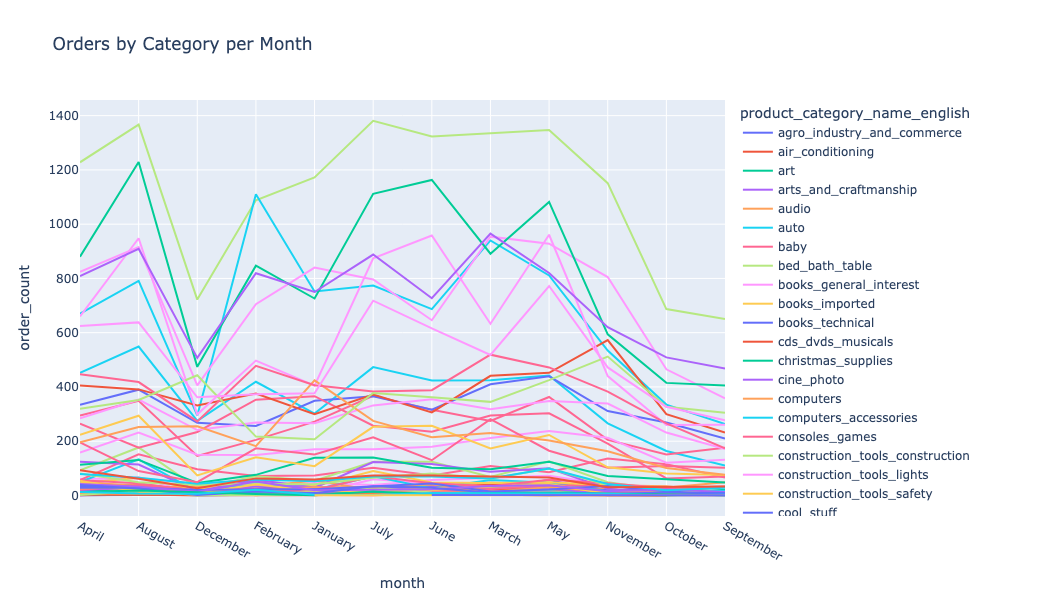

In [17]:
import plotly.express as px


months.columns = ['month', 'product_category_name_english', 'order_count']

fig = px.line(months, 
              x='month', 
              y='order_count', 
              color='product_category_name_english',
              title='Orders by Category per Month')

fig.update_layout(width=1200, height=600)
fig.show()

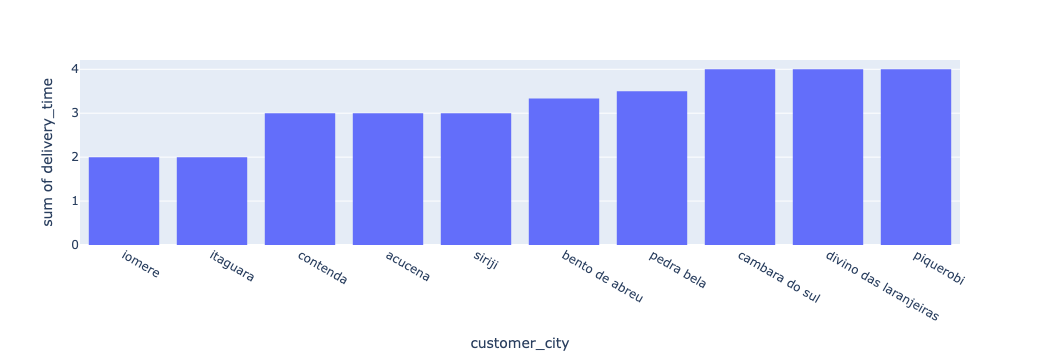

In [27]:
import plotly.express as px

fig = px.histogram(location_delivery, x='customer_city',y='delivery_time')
fig.show()

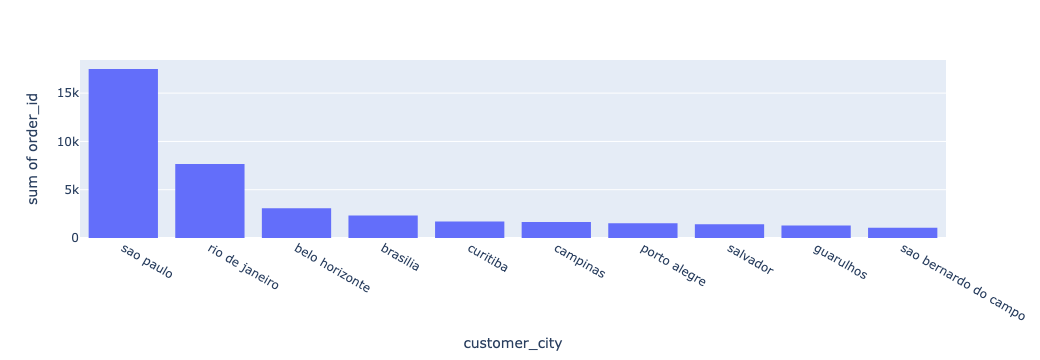

In [19]:
fig = px.histogram(location_orders, x='customer_city',y='order_id')
fig.show()

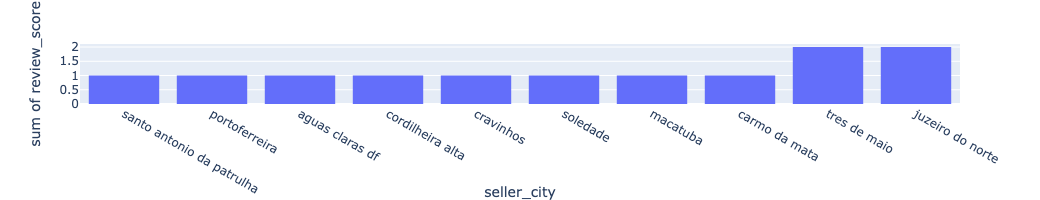

In [29]:
fig = px.histogram(seller_city_review, x='seller_city',y='review_score')
fig.update_layout(width=1050, height=200)
fig.show()

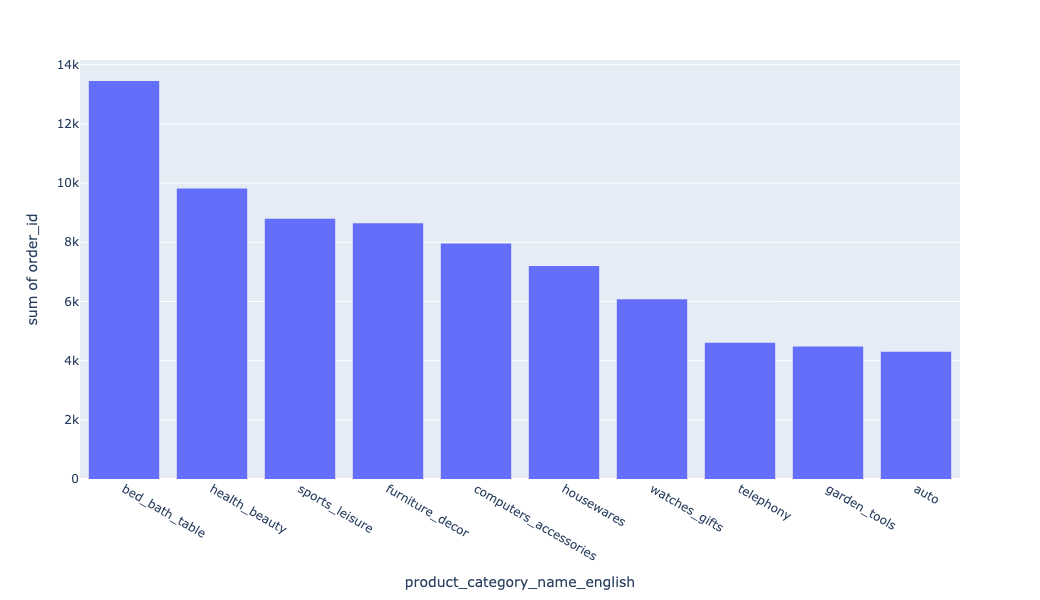

In [30]:
fig = px.histogram(product_count, x='product_category_name_english',y='order_id')
fig.update_layout(width=1000, height=600)
fig.show()

In [22]:
top = master[
    master['customer_city'].isin(master['customer_city'].value_counts().head(10).index)
]

fig = px.density_heatmap(
    top,
    x='customer_city',
    y='product_category_name_english',
    title='Orders by City and Product Category'
)
fig.update_layout(width=1000, height=600)
fig.show()

In [23]:
top_city_product = (
    master.groupby(['customer_city', 'product_category_name_english'])
    .size()
    .reset_index(name='order_count')
    .sort_values(['customer_city', 'order_count'], ascending=[True, False])
    .drop_duplicates('customer_city')
)

top_city_product = top_city_product[
    top_city_product['customer_city'].isin(
        master['customer_city'].value_counts().head(10).index
    )
]

fig = px.bar(
    top_city_product,
    x='customer_city',
    y='order_count',
    color='product_category_name_english',
    title='Most Purchased Product Category per City'
)

fig.show()

In [24]:
monthly_revenue = master.groupby('month')['payment_value'].sum().reset_index()

fig = px.line(monthly_revenue,x ='month',y='payment_value')

fig.show()
                 

In [25]:
delivery_reviews = master.groupby('delivery_time')['review_score'].mean().reset_index()

fig = px.scatter(delivery_reviews,x = 'delivery_time', y='review_score')

corr = master['delivery_time'].corr(master['review_score'])

print(corr)

fig.show()

-0.3027496662536679


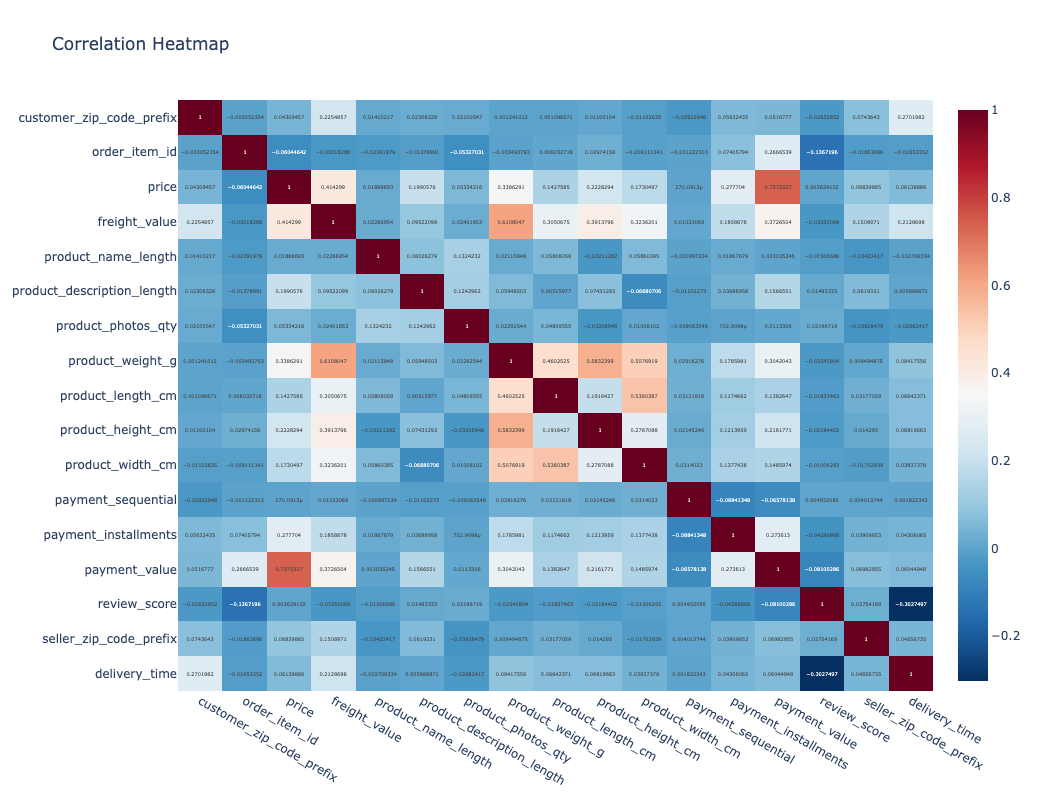

In [33]:
numeric_cols = master.select_dtypes(include='number')

#Compute correlation matrix
corr_matrix = numeric_cols.corr()

#Plot heatmap
fig = px.imshow(corr_matrix, 
                text_auto=True,          
                color_continuous_scale='RdBu_r',  
                title='Correlation Heatmap',
                aspect='auto')

fig.update_layout(width=1000, height=800)
fig.show()